[Dataset] Downloading Australian Electricity dataset …
[Dataset] Loaded 36144 timesteps  (price range $0.0400–$0.2200/kWh)
Energy-Aware GPU Cluster Scheduling — PPO vs EAR  (v4)
  8 servers | 2000 episodes | LR scheduler | sleep bonus
  price-trend state | matched eval seeds
  [NEW] Real-world AU Electricity demand → pricing
  [NEW] Multi-seed evaluation (≥5 seeds) + paired t-test
  [NEW] Price-aware task deferral queue

[Phase 0] Plotting real demand dataset...
Saved: output/real_demand_vs_price.png

─────────────────────────────────────────────────────────────────
[Seed 1/5]  global_seed=42
─────────────────────────────────────────────────────────────────
  [Phase 1] Training PPO agent (2000 episodes)...
Episode  100: Cost = 1.0475 | LR = 2.98e-04
Episode  200: Cost = 0.9723 | LR = 2.93e-04
Episode  300: Cost = 1.0817 | LR = 2.84e-04
Episode  400: Cost = 1.0865 | LR = 2.72e-04
Episode  500: Cost = 0.6817 | LR = 2.58e-04
Episode  600: Cost = 0.5391 | LR = 2.40e-04
Episode  700: Cost =

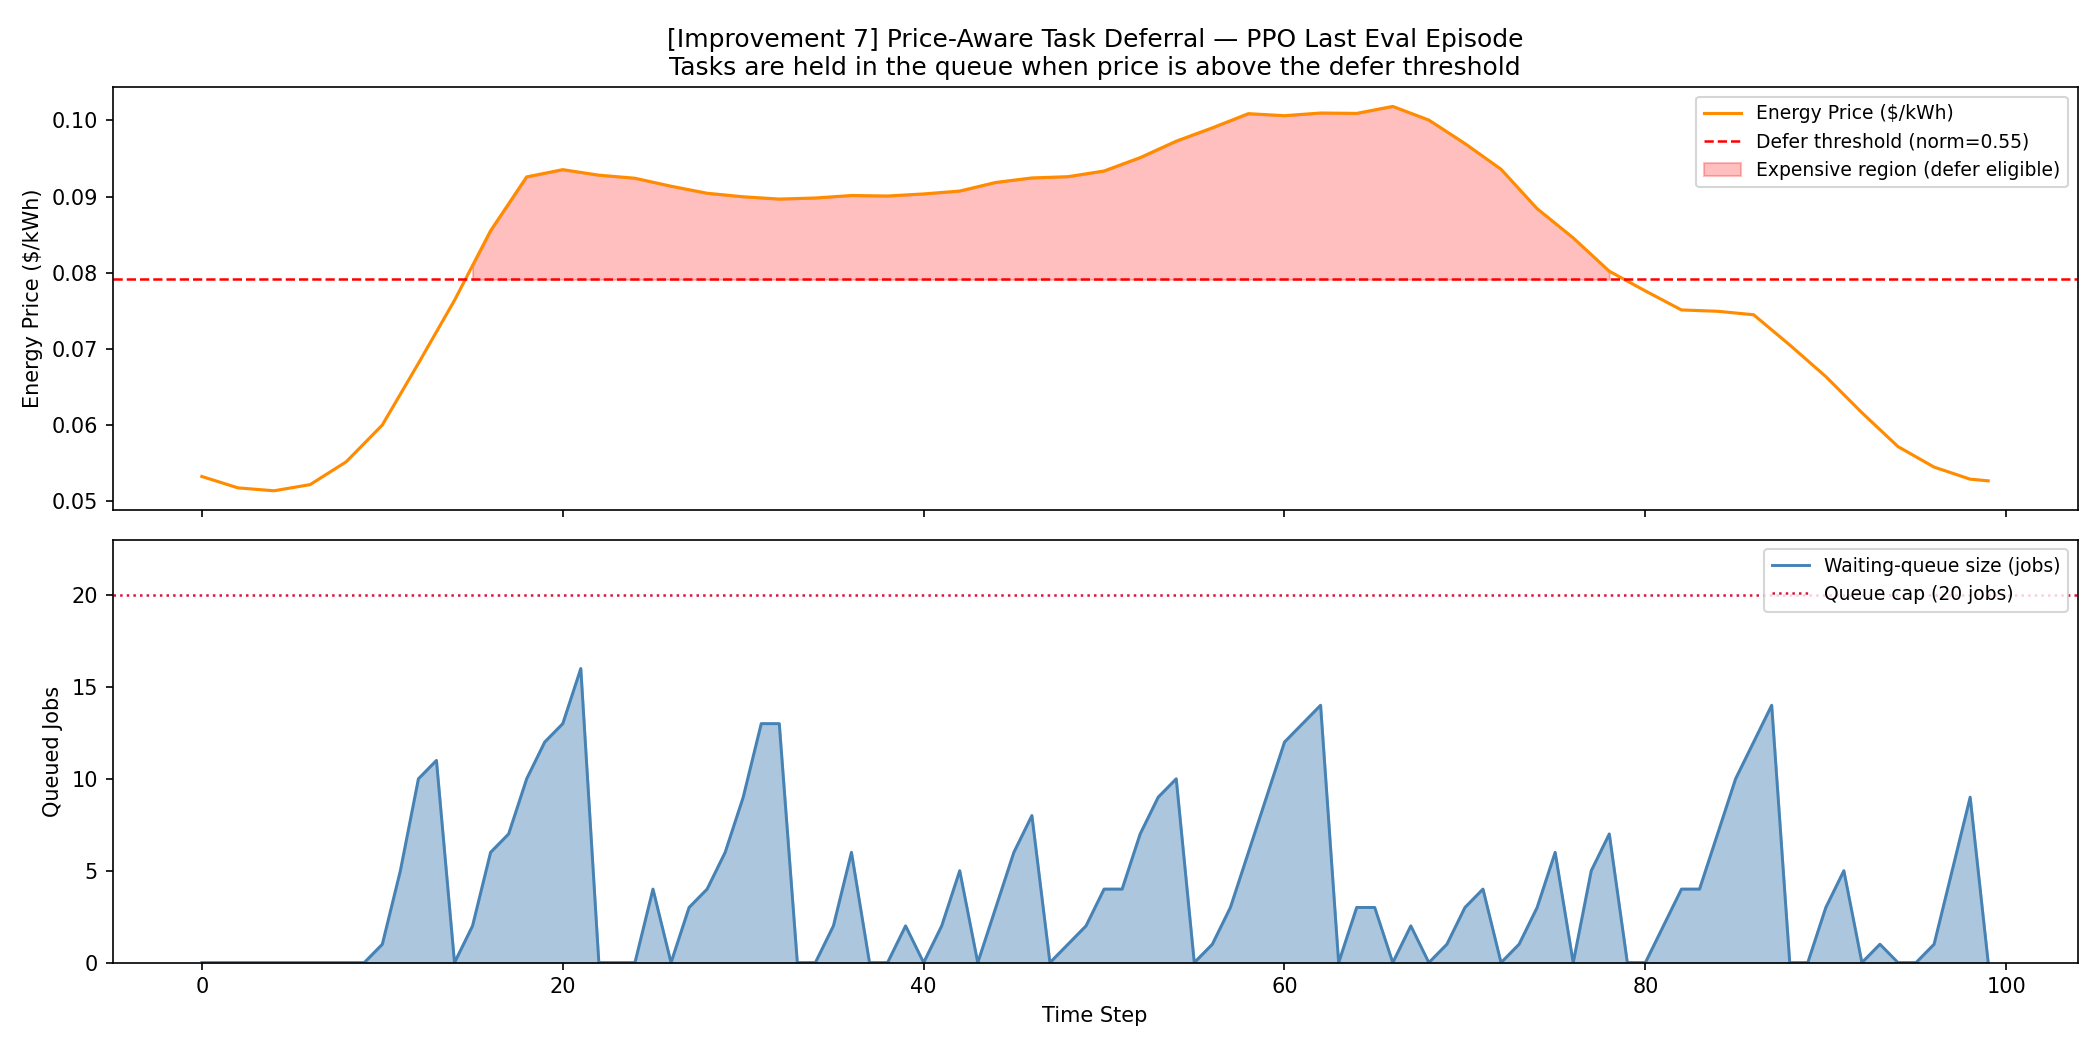

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── [Improvement 6] Real demand dataset ─────────────────────────────────────
# We use urllib so there is no hard dependency on autogluon at inference time.
# If the download fails we fall back to the synthetic price model gracefully.
import urllib.request
import io
from scipy import stats

def _load_australian_electricity_prices() -> np.ndarray:
    """
    Download the AutoGluon Australian Electricity test CSV and return a 1-D
    numpy array of energy prices ($/kWh) derived from the demand column.

    Derivation:
      • Read the 'target' column (half-hourly MW demand for 5 regions).
      • Average across all item_ids at each timestamp to get a single
        aggregate demand series.
      • Min-max normalise to [0, 1].
      • Map linearly to the price band [PRICE_MIN=0.04, PRICE_MAX=0.22] $/kWh,
        so high demand → high price (peak pricing logic).

    Returns an empty array on any failure so the rest of the code degrades
    gracefully to the synthetic EnergyPriceModel.
    """
    URL = (
        "https://autogluon.s3.amazonaws.com/datasets/timeseries/"
        "australian_electricity_subset/test.csv"
    )
    PRICE_MIN, PRICE_MAX = 0.04, 0.22

    try:
        print("[Dataset] Downloading Australian Electricity dataset …", flush=True)
        with urllib.request.urlopen(URL, timeout=30) as resp:
            raw = resp.read().decode("utf-8")

        # Parse CSV manually — columns: item_id, timestamp, target
        lines = raw.strip().splitlines()
        header = [h.strip() for h in lines[0].split(",")]
        target_idx = header.index("target")
        ts_idx     = header.index("timestamp")

        from collections import defaultdict
        ts_demand: dict = defaultdict(list)
        for line in lines[1:]:
            parts = line.split(",")
            ts    = parts[ts_idx].strip()
            val   = float(parts[target_idx].strip())
            ts_demand[ts].append(val)

        # Sort timestamps, average across regions
        sorted_ts   = sorted(ts_demand.keys())
        demand_mean = np.array([np.mean(ts_demand[t]) for t in sorted_ts],
                               dtype=np.float32)

        d_min, d_max = demand_mean.min(), demand_mean.max()
        if d_max - d_min < 1e-6:
            raise ValueError("Demand series is constant — cannot derive prices.")

        norm    = (demand_mean - d_min) / (d_max - d_min)          # [0, 1]
        prices  = PRICE_MIN + norm * (PRICE_MAX - PRICE_MIN)        # [$/kWh]

        print(f"[Dataset] Loaded {len(prices)} timesteps  "
              f"(price range ${prices.min():.4f}–${prices.max():.4f}/kWh)", flush=True)
        return prices, demand_mean, sorted_ts

    except Exception as exc:
        print(f"[Dataset] WARNING – could not load real data ({exc}). "
              "Falling back to synthetic EnergyPriceModel.", flush=True)
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32), []


# Load once at module level so all env instances share the same array.
REAL_PRICES, REAL_DEMAND_RAW, REAL_TIMESTAMPS = _load_australian_electricity_prices()

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

os.makedirs("output", exist_ok=True)


# ─────────────────────────────────────────────
# 1. Energy Pricing Model
# ─────────────────────────────────────────────

class EnergyPriceModel:
    """
    Time-of-use energy price ($/kWh).
    Base: ~0.10, range: ~0.04–0.20.
    Three multiplicative factors: hourly, daily, monthly.
    """
    BASE_PRICE = 0.10  # $/kWh

    def get_price(self, hour: float, day: int, month: int) -> float:
        return self.BASE_PRICE * self._hourly(hour) * self._daily(day) * self._monthly(month)

    def _hourly(self, hour: float) -> float:
        solar   = 0.7 - 0.3 * math.cos(2 * math.pi * (hour - 12.5) / 24.0)
        evening = 0.5 * math.exp(-0.5 * ((hour - 20.0) / 2.0) ** 2)
        return max(0.4, solar + evening)

    def _daily(self, day: int) -> float:
        mid_month   = 1.0 + 0.05 * math.sin(2 * math.pi * (day - 1) / 31.0)
        weekend_dip = 1.0 - 0.05 * math.cos(2 * math.pi * (day - 1) / 7.0)
        return mid_month * weekend_dip

    def _monthly(self, month: int) -> float:
        return 1.0 + 0.25 * math.cos(2 * math.pi * (month - 7) / 12.0)

    PRICE_MIN = 0.04
    PRICE_MAX = 0.22

    def normalise(self, price: float) -> float:
        return (price - self.PRICE_MIN) / (self.PRICE_MAX - self.PRICE_MIN + 1e-8)


# ─────────────────────────────────────────────
# [Improvement 6] Real-Data Energy Price Model
# ─────────────────────────────────────────────

class RealEnergyPriceModel:
    """
    Wraps the module-level REAL_PRICES array loaded from the Australian
    Electricity dataset.  Each environment step advances one index in the
    array (half-hourly → 30-min steps; the env uses 15-min steps so we
    interpolate between consecutive real samples).

    Falls back to the synthetic EnergyPriceModel when real data is
    exhausted or was never loaded.
    """
    PRICE_MIN = 0.04
    PRICE_MAX = 0.22

    def __init__(self, start_idx: int = 0):
        self._fallback   = EnergyPriceModel()
        self._start_idx  = start_idx
        self._has_real   = len(REAL_PRICES) > 0

    def get_price_by_index(self, idx: int, frac: float = 0.0) -> float:
        """
        Return price at position `idx` in the real array.
        `frac` ∈ [0, 1) allows linear interpolation within a half-hour window
        (useful when the env runs at 15-min resolution but data is 30-min).
        """
        if not self._has_real or len(REAL_PRICES) == 0:
            return self._fallback.get_price(0, 1, 1)   # dummy call
        i0 = (self._start_idx + idx) % len(REAL_PRICES)
        i1 = (i0 + 1) % len(REAL_PRICES)
        return float(REAL_PRICES[i0] * (1 - frac) + REAL_PRICES[i1] * frac)

    def get_demand_by_index(self, idx: int) -> float:
        """Return the raw normalised demand value (0-1) at position idx."""
        if not self._has_real or len(REAL_DEMAND_RAW) == 0:
            return 0.5
        i0 = (self._start_idx + idx) % len(REAL_DEMAND_RAW)
        d_min = float(REAL_DEMAND_RAW.min())
        d_max = float(REAL_DEMAND_RAW.max())
        return float((REAL_DEMAND_RAW[i0] - d_min) / (d_max - d_min + 1e-8))

    def normalise(self, price: float) -> float:
        return (price - self.PRICE_MIN) / (self.PRICE_MAX - self.PRICE_MIN + 1e-8)

    @property
    def has_real_data(self) -> bool:
        return self._has_real


# ─────────────────────────────────────────────
# 2. GPU Cluster Environment  (8 servers, enhanced state)
# ─────────────────────────────────────────────

class GPUClusterEnv:
    # ── [Improvement 1] Scale to 8 servers ──────────────────
    NUM_SERVERS    = 8
    CAPACITY       = 10          # max jobs per server
    LAMBDA_ARRIVAL = 2.0         # Poisson mean
    MAX_STEPS      = 100
    P_IDLE         = 50.0        # watts
    P_MAX          = 200.0       # watts
    WAKEUP_PENALTY = 100.0       # watts (one-shot addition)
    JOB_DEPART_PROB = 0.1
    SLEEP_THRESHOLD = 5          # idle steps before server sleeps
    STEP_MINUTES    = 15         # simulated clock step

    # ── [Improvement 3] Sleep bonus: 7% of a typical step reward ──
    # Typical step cost ≈ 8 servers × 125W average × (15/60)h / 1000 × $0.10/kWh ≈ $0.0025
    # 7% of that ≈ 0.000175  → expressed as positive reward
    SLEEP_BONUS = 0.000175

    # ── [Improvement 5] Price-trend amplifier ───────────────
    # When price is "expensive" (normalised > 0.6), multiply the cost penalty
    PRICE_AMPLIFIER      = 1.5   # ×1.5 penalty in expensive periods
    EXPENSIVE_THRESHOLD  = 0.6   # normalised price threshold

    # ── [Improvement 6] Real-data half-hour step = 30 min;
    #    env step = 15 min → 2 env steps per real sample ──────
    REAL_STEPS_PER_SAMPLE = 2    # env steps that share one real price sample

    # ── [Improvement 7] Price-aware task deferral ────────────
    # Action index NUM_SERVERS means "hold all new arrivals in the queue".
    DEFER_ACTION     = 8          # == NUM_SERVERS; keep out-of-band from server ids
    MAX_QUEUE_SIZE   = 20         # hard cap on queued jobs (prevents unbounded accumulation)
    DEFER_THRESHOLD  = 0.55       # normalised price above which deferral is worthwhile
    QUEUE_HOLD_COST  = 5e-6       # $/job/step penalty to discourage infinite waiting
    MAX_DEFER_STEPS  = 8          # SLA: force-dispatch after this many consecutive defers
    FORECAST_HORIZON = 6          # steps ahead used by EAR to predict a price dip

    def __init__(self, seed: int = None):
        # ── [Improvement 6] Choose a random start offset in the real series ──
        start_idx = 0
        if len(REAL_PRICES) > 0:
            rng_init  = np.random.RandomState(seed if seed is not None else 0)
            start_idx = rng_init.randint(0, max(1, len(REAL_PRICES) - 200))
        self.real_price_model = RealEnergyPriceModel(start_idx=start_idx)
        self.synth_price_model = EnergyPriceModel()   # kept for fallback & normalise
        self._rng = np.random.RandomState(seed)       # per-instance RNG for matched seeds
        self.reset()

    # ── public API ──────────────────────────────────────────

    def reset(self):
        self.loads       = np.zeros(self.NUM_SERVERS, dtype=np.float32)
        self.idle_counts = np.zeros(self.NUM_SERVERS, dtype=np.int32)
        self.sleeping    = np.zeros(self.NUM_SERVERS, dtype=np.bool_)
        self.step_count  = 0

        # ── [Improvement 7] Deferral queue state ─────────────
        self.task_queue          = 0    # number of jobs waiting in the queue
        self.consecutive_defers  = 0    # steps in a row the defer action was chosen

        # Randomise starting time (using instance RNG so seeds propagate)
        start_hour  = self._rng.uniform(0, 24)
        start_day   = self._rng.randint(1, 29)
        start_month = self._rng.randint(1, 13)
        self._sim_minutes = (
            start_month * 30 * 24 * 60
            + start_day * 24 * 60
            + start_hour * 60
        )

        # ── [Improvement 5] Initialise price trend tracking ──
        self._prev_price = self._get_energy_price()

        return self._get_state()

    def step(self, action: int):
        """
        action ∈ {0 … NUM_SERVERS-1}  → dispatch to that server
        action == DEFER_ACTION (8)     → hold new arrivals in the waiting queue

        [Improvement 7] When the defer action is chosen:
          • New arrivals are added to task_queue (capped at MAX_QUEUE_SIZE).
          • A small holding cost is charged per queued job.
          • If consecutive_defers reaches MAX_DEFER_STEPS the oldest batch
            is force-dispatched to the least-loaded server (SLA guarantee).
        When a dispatch action is chosen:
          • Queued jobs are dispatched first (FIFO priority), then new
            arrivals fill remaining capacity on the chosen server.
        """
        assert 0 <= action <= self.DEFER_ACTION

        n_arrivals = self._rng.poisson(self.LAMBDA_ARRIVAL)
        raw_price  = self._get_energy_price()
        norm_price = self.real_price_model.normalise(raw_price)

        wakeup_energy  = 0.0
        queue_penalty  = 0.0
        forced_dispatch = False

        # ── [Improvement 7] Handle defer vs dispatch ─────────
        if action == self.DEFER_ACTION:
            # Enqueue new arrivals (respect queue cap)
            space = max(0, self.MAX_QUEUE_SIZE - self.task_queue)
            self.task_queue         += min(n_arrivals, space)
            self.consecutive_defers += 1

            # SLA: force-dispatch if deferred too long
            if self.consecutive_defers >= self.MAX_DEFER_STEPS and self.task_queue > 0:
                action = int(np.argmin(self.loads))   # least-loaded server
                forced_dispatch = True
                # fall through to dispatch logic below
            else:
                # Pure defer step: just charge holding cost, no server dispatch
                queue_penalty = self.task_queue * self.QUEUE_HOLD_COST

                # Job departures still happen (servers keep running)
                for s in range(self.NUM_SERVERS):
                    departures = self._rng.binomial(int(self.loads[s]), self.JOB_DEPART_PROB)
                    self.loads[s] = max(0, self.loads[s] - departures)

                # Sleep tracking
                sleep_bonus = 0.0
                for s in range(self.NUM_SERVERS):
                    if self.loads[s] == 0:
                        self.idle_counts[s] += 1
                        if self.idle_counts[s] == self.SLEEP_THRESHOLD:
                            self.sleeping[s] = True
                            sleep_bonus += self.SLEEP_BONUS
                        elif self.idle_counts[s] > self.SLEEP_THRESHOLD:
                            self.sleeping[s] = True
                    else:
                        self.idle_counts[s] = 0
                        self.sleeping[s]    = False

                total_power = self._compute_total_power()
                energy_kwh  = total_power * (self.STEP_MINUTES / 60.0) / 1000.0
                cost        = energy_kwh * raw_price + queue_penalty
                if norm_price > self.EXPENSIVE_THRESHOLD:
                    cost *= self.PRICE_AMPLIFIER

                self._prev_price   = raw_price
                self._sim_minutes += self.STEP_MINUTES
                self.step_count   += 1
                done = self.step_count >= self.MAX_STEPS

                info   = {
                    "raw_price": raw_price, "total_power_w": total_power,
                    "cost": cost, "deferred": True, "queue_size": self.task_queue,
                    "forced_dispatch": False,
                }
                reward = -cost + sleep_bonus
                return self._get_state(), reward, done, info

        # ── Dispatch path (normal action OR force-dispatch) ───
        self.consecutive_defers = 0   # reset defer streak

        # Overflow guard: redirect to least-loaded server
        if self.loads[action] >= self.CAPACITY:
            action = int(np.argmin(self.loads))

        # Wakeup penalty
        if self.sleeping[action]:
            wakeup_energy = self.WAKEUP_PENALTY
            self.sleeping[action] = False

        # Dispatch queued jobs first, then new arrivals
        total_to_dispatch = self.task_queue + n_arrivals
        self.task_queue   = 0          # drain queue
        self.loads[action] = min(self.CAPACITY, self.loads[action] + total_to_dispatch)

        # Job departures (stochastic)
        for s in range(self.NUM_SERVERS):
            departures = self._rng.binomial(int(self.loads[s]), self.JOB_DEPART_PROB)
            self.loads[s] = max(0, self.loads[s] - departures)

        # ── [Improvement 3] Track sleep transitions for bonus ──
        sleep_bonus = 0.0
        for s in range(self.NUM_SERVERS):
            if self.loads[s] == 0:
                self.idle_counts[s] += 1
                if self.idle_counts[s] == self.SLEEP_THRESHOLD:
                    self.sleeping[s] = True
                    sleep_bonus += self.SLEEP_BONUS
                elif self.idle_counts[s] > self.SLEEP_THRESHOLD:
                    self.sleeping[s] = True
            else:
                self.idle_counts[s] = 0
                self.sleeping[s]    = False

        # Energy & cost
        total_power = self._compute_total_power() + wakeup_energy
        energy_kwh  = total_power * (self.STEP_MINUTES / 60.0) / 1000.0
        cost        = energy_kwh * raw_price

        # ── [Improvement 5] Price-trend reward amplification ──
        if norm_price > self.EXPENSIVE_THRESHOLD:
            cost *= self.PRICE_AMPLIFIER

        # Advance simulated clock
        self._prev_price    = raw_price
        self._sim_minutes  += self.STEP_MINUTES
        self.step_count    += 1
        done = self.step_count >= self.MAX_STEPS

        info   = {
            "raw_price": raw_price, "total_power_w": total_power,
            "cost": cost, "deferred": False, "queue_size": self.task_queue,
            "forced_dispatch": forced_dispatch,
        }
        reward = -cost + sleep_bonus
        return self._get_state(), reward, done, info

    # ── internals ────────────────────────────────────────────

    def _get_state(self) -> np.ndarray:
        """
        State vector (dim = 8 + 8 + 8 + 1 + 1 + 2 + 1 + 2 = 31):
          [norm_loads ×8]            normalised job counts
          [sleep_flags ×8]           1 if server is sleeping
          [norm_idle_counts ×8]      [Improvement 3] fraction toward sleep threshold
          [norm_price]               normalised energy price
          [price_trend]              [Improvement 5] +1 rising / -1 falling / 0 flat
          [tod_sin, tod_cos]         time-of-day encoding
          [norm_demand]              [Improvement 6] normalised real-world demand (0-1)
          [norm_queue_size]          [Improvement 7] queue fill level (0-1)
          [norm_defer_steps]         [Improvement 7] consecutive defer fraction (0-1)
        """
        norm_loads       = self.loads / self.CAPACITY
        sleep_flags      = self.sleeping.astype(np.float32)

        # ── [Improvement 3] Sleep timer ──────────────────────
        norm_idle        = np.clip(self.idle_counts / self.SLEEP_THRESHOLD, 0.0, 1.0).astype(np.float32)

        raw_price        = self._get_energy_price()
        norm_price       = self.real_price_model.normalise(raw_price)

        # ── [Improvement 5] Price trend ──────────────────────
        delta = raw_price - self._prev_price
        if abs(delta) < 1e-6:
            price_trend = 0.0
        else:
            price_trend = 1.0 if delta > 0 else -1.0

        hour     = self._current_hour()
        angle    = 2 * math.pi * hour / 24.0
        tod_sin  = math.sin(angle)
        tod_cos  = math.cos(angle)

        # ── [Improvement 6] Real demand feature ──────────────
        real_idx    = self.step_count // self.REAL_STEPS_PER_SAMPLE
        norm_demand = self.real_price_model.get_demand_by_index(real_idx)

        # ── [Improvement 7] Deferral queue features ──────────
        norm_queue_size  = float(self.task_queue) / max(1, self.MAX_QUEUE_SIZE)
        norm_defer_steps = float(self.consecutive_defers) / max(1, self.MAX_DEFER_STEPS)

        return np.array(
            list(norm_loads) + list(sleep_flags) + list(norm_idle)
            + [norm_price, price_trend, tod_sin, tod_cos, norm_demand,
               norm_queue_size, norm_defer_steps],
            dtype=np.float32,
        )  # dim = 31

    def _get_energy_price(self) -> float:
        """
        [Improvement 6] Use real-data price when available; otherwise fall back
        to the synthetic time-of-use model.
        Each real sample covers REAL_STEPS_PER_SAMPLE env steps.
        Within a sample we linearly interpolate via `frac`.
        """
        if self.real_price_model.has_real_data:
            real_idx = self.step_count // self.REAL_STEPS_PER_SAMPLE
            frac     = (self.step_count % self.REAL_STEPS_PER_SAMPLE) / self.REAL_STEPS_PER_SAMPLE
            return self.real_price_model.get_price_by_index(real_idx, frac)
        # Fallback
        total_minutes = self._sim_minutes
        hour  = (total_minutes / 60.0) % 24.0
        day   = int((total_minutes // (24 * 60)) % 31) + 1
        month = int((total_minutes // (30 * 24 * 60)) % 12) + 1
        return self.synth_price_model.get_price(hour, day, month)

    def _current_hour(self) -> float:
        return (self._sim_minutes / 60.0) % 24.0

    def _compute_total_power(self) -> float:
        total = 0.0
        for s in range(self.NUM_SERVERS):
            if self.sleeping[s]:
                continue                  # sleeping servers draw ~0W
            util = np.clip(self.loads[s] / self.CAPACITY, 0.0, 1.0)
            total += self.P_IDLE + (self.P_MAX - self.P_IDLE) * util ** 2
        return total

    def predicted_power(self, server: int, extra_jobs: int = 1) -> float:
        new_load = min(self.CAPACITY, self.loads[server] + extra_jobs)
        util = np.clip(new_load / self.CAPACITY, 0.0, 1.0)
        p = self.P_IDLE + (self.P_MAX - self.P_IDLE) * util ** 2
        if self.sleeping[server]:
            p += self.WAKEUP_PENALTY
        return p


# ─────────────────────────────────────────────
# 3. PPO Agent (LSTM ActorCritic)
# ─────────────────────────────────────────────

# ── [Improvement 1] updated dims for 8 servers ──────────────
# ── [Improvement 7] +2 state features (queue_size, defer_steps); +1 action (defer) ──
STATE_DIM   = 31    # 8×loads + 8×sleep_flags + 8×idle_norm + norm_price + trend + sin + cos + demand + queue + defer_frac
NUM_ACTIONS = GPUClusterEnv.NUM_SERVERS + 1   # 8 servers + 1 defer action
HIDDEN_SIZE = 128   # larger hidden for more servers


class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm  = nn.LSTM(STATE_DIM, HIDDEN_SIZE, batch_first=True)
        self.actor  = nn.Linear(HIDDEN_SIZE, NUM_ACTIONS)
        self.critic = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x, hx=None):
        out, hx = self.lstm(x, hx)
        h       = out[:, -1, :]
        logits  = self.actor(h)
        value   = self.critic(h).squeeze(-1)
        return logits, value, hx

    def act(self, state_np, hx):
        x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        with torch.no_grad():
            logits, value, hx = self.forward(x, hx)
        probs   = torch.softmax(logits, dim=-1)
        dist    = torch.distributions.Categorical(probs)
        action  = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob.item(), value.item(), hx

    def init_hidden(self):
        return (
            torch.zeros(1, 1, HIDDEN_SIZE),
            torch.zeros(1, 1, HIDDEN_SIZE),
        )


class PPOAgent:
    GAMMA        = 0.99
    CLIP_EPS     = 0.2
    LR           = 3e-4
    LR_MIN       = 1e-5          # [Improvement 2] floor for cosine LR scheduler
    EPOCHS       = 4
    ENTROPY_COEF = 0.01

    def __init__(self, num_episodes: int = 2000):
        self.net       = ActorCritic()
        self.optimizer = optim.Adam(self.net.parameters(), lr=self.LR)

        # ── [Improvement 2] Cosine-annealing scheduler ──────
        # Decays LR from LR down to LR_MIN over num_episodes steps.
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=num_episodes,
            eta_min=self.LR_MIN,
        )

    def train(self, num_episodes: int = 2000):
        env = GPUClusterEnv()       # training env uses global np seed
        episode_costs = []

        for ep in range(num_episodes):
            state = env.reset()
            hx    = self.net.init_hidden()

            states, actions, rewards, log_probs_old, values_old = [], [], [], [], []
            done       = False
            total_cost = 0.0

            # ── Trajectory collection ────────────────────────
            while not done:
                action, lp, val, hx = self.net.act(state, hx)
                next_state, reward, done, info = env.step(action)
                total_cost += info["cost"]

                states.append(state)
                actions.append(action)
                rewards.append(reward)
                log_probs_old.append(lp)
                values_old.append(val)
                state = next_state

            episode_costs.append(total_cost)

            # ── Discounted returns ───────────────────────────
            T       = len(rewards)
            returns = np.zeros(T, dtype=np.float32)
            running = 0.0
            for t in reversed(range(T)):
                running    = rewards[t] + self.GAMMA * running
                returns[t] = running

            values_np  = np.array(values_old, dtype=np.float32)
            advantages = returns - values_np
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # ── PPO update ───────────────────────────────────
            states_t         = torch.tensor(np.array(states), dtype=torch.float32)
            actions_t        = torch.tensor(actions, dtype=torch.long)
            returns_t        = torch.tensor(returns, dtype=torch.float32)
            advantages_t     = torch.tensor(advantages, dtype=torch.float32)
            log_probs_old_t  = torch.tensor(log_probs_old, dtype=torch.float32)

            for _ in range(self.EPOCHS):
                x  = states_t.unsqueeze(0)
                h0 = torch.zeros(1, 1, HIDDEN_SIZE)
                c0 = torch.zeros(1, 1, HIDDEN_SIZE)
                lstm_out, _ = self.net.lstm(x, (h0, c0))
                h           = lstm_out.squeeze(0)

                logits     = self.net.actor(h)
                values_new = self.net.critic(h).squeeze(-1)

                dist          = torch.distributions.Categorical(logits=logits)
                log_probs_new = dist.log_prob(actions_t)
                entropy       = dist.entropy().mean()

                ratio  = torch.exp(log_probs_new - log_probs_old_t)
                surr1  = ratio * advantages_t
                surr2  = torch.clamp(ratio, 1 - self.CLIP_EPS, 1 + self.CLIP_EPS) * advantages_t
                actor_loss  = -torch.min(surr1, surr2).mean()
                critic_loss = nn.functional.mse_loss(values_new, returns_t)
                loss        = actor_loss + 0.5 * critic_loss - self.ENTROPY_COEF * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), 0.5)
                self.optimizer.step()

            # ── [Improvement 2] Step the LR scheduler each episode ──
            self.scheduler.step()

            current_lr = self.scheduler.get_last_lr()[0]
            if (ep + 1) % 100 == 0:
                print(
                    f"Episode {ep + 1:>4}: Cost = {total_cost:.4f} | LR = {current_lr:.2e}"
                )

        return episode_costs

    def select_action(self, state: np.ndarray, hx):
        action, lp, val, hx = self.net.act(state, hx)
        return action, hx


# ─────────────────────────────────────────────
# 4. EAR Heuristic Policy
# ─────────────────────────────────────────────

def ear_policy(env: GPUClusterEnv) -> int:
    """
    Energy-Aware Ready (EAR): price-aware, myopic dispatch heuristic.

    Always dispatches to the server with minimum predicted energy cost.
    Deferral has been removed from EAR; only PPO may use the defer action.
    """
    raw_price = env._get_energy_price()

    # Pick server with minimum predicted cost
    best_server = 0
    best_cost   = float("inf")

    for s in range(env.NUM_SERVERS):
        pred_power = env.predicted_power(s, extra_jobs=1)
        pred_cost  = pred_power * (env.STEP_MINUTES / 60.0) / 1000.0 * raw_price
        if pred_cost < best_cost:
            best_cost   = pred_cost
            best_server = s

    return best_server


# ─────────────────────────────────────────────
# 5. Evaluation  (matched seeds)
# ─────────────────────────────────────────────

def evaluate(agent: PPOAgent, num_episodes: int = 20):
    """
    [Improvement 4] Both PPO and EAR share the same episode seeds so they
    face identical starting conditions, enabling a fair cost comparison.
    [Improvement 7] Also tracks deferral statistics (defer rate, queue size).
    """
    ppo_costs        = []
    ear_costs        = []
    ppo_load_history  = None
    ppo_price_history = None
    ppo_defer_history = None   # [Improvement 7] queue size over time

    # Pre-generate matched seeds
    eval_seeds = np.random.randint(0, 2**31 - 1, size=num_episodes)

    ppo_total_defers = 0
    ppo_total_steps  = 0
    ear_total_steps  = 0

    for ep in range(num_episodes):
        seed = int(eval_seeds[ep])

        # ── PPO evaluation ───────────────────────────────────
        env   = GPUClusterEnv(seed=seed)
        state = env.reset()
        hx    = agent.net.init_hidden()
        total_cost  = 0.0
        load_hist   = []
        price_hist  = []
        defer_hist  = []   # [Improvement 7]
        done = False
        while not done:
            load_hist.append(env.loads.copy())
            price_hist.append(env._get_energy_price())
            defer_hist.append(env.task_queue)
            action, hx = agent.select_action(state, hx)
            state, reward, done, info = env.step(action)
            total_cost += info["cost"]
            ppo_total_steps  += 1
            if info.get("deferred", False):
                ppo_total_defers += 1
        ppo_costs.append(total_cost)
        if ep == num_episodes - 1:
            ppo_load_history  = np.array(load_hist)
            ppo_price_history = np.array(price_hist)
            ppo_defer_history = np.array(defer_hist)

        # ── EAR evaluation — same seed ────────────────────────
        env   = GPUClusterEnv(seed=seed)
        state = env.reset()
        total_cost_ear = 0.0
        done = False
        while not done:
            action = ear_policy(env)
            state, reward, done, info = env.step(action)
            total_cost_ear += info["cost"]
            ear_total_steps  += 1
        ear_costs.append(total_cost_ear)

    ppo_defer_rate = ppo_total_defers / max(1, ppo_total_steps)
    print(f"  PPO defer rate: {ppo_defer_rate:.1%}")

    return {
        "ppo_costs":         np.array(ppo_costs),
        "ear_costs":         np.array(ear_costs),
        "ppo_load_history":  ppo_load_history,
        "ppo_price_history": ppo_price_history,
        "ppo_defer_history": ppo_defer_history,
        "ppo_defer_rate":    ppo_defer_rate,
    }


# ─────────────────────────────────────────────
# 6. Visualisations
# ─────────────────────────────────────────────

def plot_training_curve(episode_costs):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    x  = np.arange(1, len(episode_costs) + 1)
    ec = np.array(episode_costs)

    # Raw + moving average
    window = 50
    ma = np.convolve(ec, np.ones(window) / window, mode="valid")
    x_ma = np.arange(window, len(ec) + 1)

    axes[0].plot(x, ec, color="steelblue", alpha=0.2, linewidth=0.8, label="Raw")
    axes[0].plot(x_ma, ma, color="steelblue", linewidth=2.5,
                 label=f"Moving avg (w={window})")
    axes[0].set_ylabel("Total Energy Cost ($)")
    axes[0].set_title("PPO Training Curve — Energy Cost per Episode  (2 000 episodes, 8 servers)")
    axes[0].legend()

    # Learning rate curve (cosine)
    lr_start = PPOAgent.LR
    lr_min   = PPOAgent.LR_MIN
    n = len(episode_costs)
    lr_curve = [lr_min + 0.5 * (lr_start - lr_min) * (1 + math.cos(math.pi * t / n))
                for t in range(n)]
    axes[1].plot(x, lr_curve, color="darkorange", linewidth=1.8)
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Learning Rate")
    axes[1].set_title("Cosine-Annealing Learning Rate Schedule")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.savefig("output/training_curve.png", dpi=150)
    plt.close()
    print("Saved: output/training_curve.png")


def plot_energy_comparison(results):
    ppo_costs = results["ppo_costs"]
    ear_costs = results["ear_costs"]

    ppo_mean, ppo_std = ppo_costs.mean(), ppo_costs.std()
    ear_mean, ear_std = ear_costs.mean(), ear_costs.std()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart
    bars = axes[0].bar(
        ["PPO (RL)", "EAR (Heuristic)"],
        [ppo_mean, ear_mean],
        yerr=[ppo_std, ear_std],
        color=["steelblue", "coral"],
        capsize=8, width=0.5,
    )
    axes[0].set_ylabel("Mean Total Energy Cost ($)")
    axes[0].set_title("Mean Cost — PPO vs EAR\n(matched seeds, 8 servers)")
    for bar, mean in zip(bars, [ppo_mean, ear_mean]):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, mean + ppo_std * 0.05,
            f"${mean:.4f}", ha="center", va="bottom", fontsize=11,
        )

    # Episode-level scatter (PPO - EAR per seed)
    diff = ppo_costs - ear_costs
    ep_x = np.arange(1, len(diff) + 1)
    colors = ["steelblue" if d <= 0 else "coral" for d in diff]
    axes[1].bar(ep_x, diff, color=colors, width=0.8)
    axes[1].axhline(0, color="k", linewidth=1)
    axes[1].set_xlabel("Evaluation Episode (matched seed)")
    axes[1].set_ylabel("PPO cost − EAR cost ($)")
    axes[1].set_title("Per-Episode Cost Difference\n(blue = PPO wins, red = EAR wins)")

    plt.tight_layout()
    plt.savefig("output/energy_comparison.png", dpi=150)
    plt.close()
    print("Saved: output/energy_comparison.png")


def plot_load_heatmap_ppo(load_history):
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(
        load_history.T, aspect="auto", cmap="viridis",
        origin="lower", interpolation="nearest",
    )
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Server ID")
    ax.set_yticks(range(GPUClusterEnv.NUM_SERVERS))
    ax.set_yticklabels([f"Server {i}" for i in range(GPUClusterEnv.NUM_SERVERS)])
    ax.set_title("PPO Server Load Heatmap — 8 servers (last eval episode)")
    plt.colorbar(im, ax=ax, label="Jobs")
    plt.tight_layout()
    plt.savefig("output/load_heatmap_ppo.png", dpi=150)
    plt.close()
    print("Saved: output/load_heatmap_ppo.png")


def plot_price_curve(price_history, load_history):
    steps      = np.arange(len(price_history))
    total_load = load_history.sum(axis=1)

    # Mark expensive periods
    pm        = EnergyPriceModel()
    norm_prices = np.array([pm.normalise(p) for p in price_history])
    expensive   = norm_prices > GPUClusterEnv.EXPENSIVE_THRESHOLD

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(steps, price_history, color="orange", linewidth=2, label="Energy Price ($/kWh)")
    # Shade expensive windows
    ax1.fill_between(steps, 0, price_history, where=expensive,
                     color="red", alpha=0.15, label="Expensive period (amplified penalty)")
    ax1.set_xlabel("Time Step (15-min intervals)")
    ax1.set_ylabel("Energy Price ($/kWh)", color="orange")
    ax1.tick_params(axis="y", labelcolor="orange")

    ax2 = ax1.twinx()
    ax2.fill_between(steps, total_load, alpha=0.25, color="steelblue", label="Total Load (PPO)")
    ax2.plot(steps, total_load, color="steelblue", linewidth=1.5)
    ax2.set_ylabel("Total Jobs (all 8 servers)", color="steelblue")
    ax2.tick_params(axis="y", labelcolor="steelblue")

    src = "Real (AU Electricity)" if len(REAL_PRICES) > 0 else "Synthetic TOU model"
    ax1.set_title(f"Energy Price vs PPO Load Decisions  [{src}]\n"
                  "Red shading = expensive periods with amplified (×1.5) reward penalty")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.savefig("output/price_curve.png", dpi=150)
    plt.close()
    print("Saved: output/price_curve.png")


def plot_real_demand_vs_price():
    """
    [Improvement 6] Plot the full Australian Electricity demand series
    alongside the derived $/kWh prices to illustrate the data source.
    Only called when real data was loaded successfully.
    """
    if len(REAL_PRICES) == 0:
        print("[Plot] Skipping demand plot — no real data loaded.")
        return

    n      = len(REAL_PRICES)
    steps  = np.arange(n)

    # Show at most 2000 points for readability
    stride = max(1, n // 2000)
    s      = steps[::stride]
    p      = REAL_PRICES[::stride]
    d_raw  = REAL_DEMAND_RAW[::stride]
    d_min, d_max = REAL_DEMAND_RAW.min(), REAL_DEMAND_RAW.max()
    d_norm = (d_raw - d_min) / (d_max - d_min + 1e-8)

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax1.plot(s, p, color="darkorange", linewidth=1.2,
             label="Derived Price ($/kWh)")
    ax1.set_xlabel("Sample Index (half-hourly)")
    ax1.set_ylabel("Energy Price ($/kWh)", color="darkorange")
    ax1.tick_params(axis="y", labelcolor="darkorange")

    ax2 = ax1.twinx()
    ax2.fill_between(s, d_norm, alpha=0.20, color="teal")
    ax2.plot(s, d_norm, color="teal", linewidth=0.8, alpha=0.7,
             label="Norm. Demand (AU Electricity)")
    ax2.set_ylabel("Normalised Demand", color="teal")
    ax2.tick_params(axis="y", labelcolor="teal")

    ax1.set_title(
        f"Australian Electricity Dataset — {n} half-hourly samples\n"
        "Demand → price mapping used in RL environment (peak demand = peak price)"
    )
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.savefig("output/real_demand_vs_price.png", dpi=150)
    plt.close()
    print("Saved: output/real_demand_vs_price.png")


def plot_sleep_analysis(load_history):
    """Extra plot: shows how many servers are sleeping at each step."""
    # We can't recover sleep state post-hoc from loads alone here, but we can
    # show utilisation distribution across 8 servers as a proxy.
    fig, ax = plt.subplots(figsize=(14, 4))
    idle_mask = (load_history == 0).astype(float)
    avg_idle  = idle_mask.mean(axis=1)  # fraction of servers idle per step

    ax.fill_between(np.arange(len(avg_idle)), avg_idle,
                    alpha=0.4, color="mediumpurple")
    ax.plot(avg_idle, color="mediumpurple", linewidth=1.5,
            label="Fraction of servers idle (load=0)")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Fraction Idle")
    ax.set_title("Server Idle Rate — PPO Last Eval Episode  (8 servers)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.savefig("output/sleep_analysis.png", dpi=150)
    plt.close()
    print("Saved: output/sleep_analysis.png")


def plot_deferral_analysis(price_history, defer_history):
    """
    [Improvement 7] Visualise the relationship between energy price and
    task deferral queue size over the last eval episode.

    Top panel  – energy price over time with the defer threshold marked.
    Bottom panel – queue size over time, highlighting steps where jobs were
                   held back waiting for cheaper electricity.
    """
    steps = np.arange(len(price_history))

    # Normalise prices for the threshold overlay
    p_min = price_history.min()
    p_max = price_history.max()
    norm_prices = (price_history - p_min) / (p_max - p_min + 1e-8)
    threshold_price = (
        p_min + GPUClusterEnv.DEFER_THRESHOLD * (p_max - p_min)
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # ── Top: price curve + defer threshold ───────────────────
    ax1.plot(steps, price_history, color="darkorange", linewidth=1.5,
             label="Energy Price ($/kWh)")
    ax1.axhline(threshold_price, color="red", linestyle="--", linewidth=1.2,
                label=f"Defer threshold (norm={GPUClusterEnv.DEFER_THRESHOLD})")

    # Shade expensive regions (where deferral is triggered)
    expensive = price_history >= threshold_price
    ax1.fill_between(steps, price_history, threshold_price,
                     where=expensive, alpha=0.25, color="red",
                     label="Expensive region (defer eligible)")

    ax1.set_ylabel("Energy Price ($/kWh)")
    ax1.set_title(
        "[Improvement 7] Price-Aware Task Deferral — PPO Last Eval Episode\n"
        "Tasks are held in the queue when price is above the defer threshold"
    )
    ax1.legend(loc="upper right", fontsize=9)

    # ── Bottom: queue size over time ──────────────────────────
    ax2.fill_between(steps, defer_history, alpha=0.45, color="steelblue")
    ax2.plot(steps, defer_history, color="steelblue", linewidth=1.4,
             label="Waiting-queue size (jobs)")
    ax2.axhline(GPUClusterEnv.MAX_QUEUE_SIZE, color="crimson", linestyle=":",
                linewidth=1.2, label=f"Queue cap ({GPUClusterEnv.MAX_QUEUE_SIZE} jobs)")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Queued Jobs")
    ax2.set_ylim(0, GPUClusterEnv.MAX_QUEUE_SIZE * 1.15)
    ax2.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.savefig("output/deferral_analysis.png", dpi=150)
    plt.close()
    print("Saved: output/deferral_analysis.png")


# ─────────────────────────────────────────────
# Entry point
# ─────────────────────────────────────────────

def main():
    print("=" * 65)
    print("Energy-Aware GPU Cluster Scheduling — PPO vs EAR  (v4)")
    print("  8 servers | 2000 episodes | LR scheduler | sleep bonus")
    print("  price-trend state | matched eval seeds")
    print("  [NEW] Real-world AU Electricity demand → pricing")
    print("  [NEW] Multi-seed evaluation (≥5 seeds) + paired t-test")
    print("  [NEW] Price-aware task deferral queue")
    print("=" * 65)

    NUM_TRAIN_EPS = 2000
    NUM_EVAL_EPS  = 350
    NUM_SEEDS     = 5          # ≥5 seeds required for statistical validity

    # ── [Improvement 6] Plot the real dataset first ───────────
    print("\n[Phase 0] Plotting real demand dataset...")
    plot_real_demand_vs_price()

    # ── Multi-seed training & evaluation loop ─────────────────
    # Each seed controls: torch RNG (network init) + numpy RNG (env stochasticity).
    GLOBAL_SEEDS = [42, 7, 123, 2024, 999]   # exactly NUM_SEEDS distinct seeds
    assert len(GLOBAL_SEEDS) == NUM_SEEDS

    all_ppo_costs = []   # shape: (NUM_SEEDS, NUM_EVAL_EPS)
    all_ear_costs = []
    last_results  = None
    last_episode_costs = None

    for seed_idx, global_seed in enumerate(GLOBAL_SEEDS):
        print(f"\n{'─'*65}")
        print(f"[Seed {seed_idx + 1}/{NUM_SEEDS}]  global_seed={global_seed}")
        print(f"{'─'*65}")

        # Fix both torch and numpy so network weights & env dynamics differ
        # reproducibly across seeds but consistently within a seed.
        torch.manual_seed(global_seed)
        np.random.seed(global_seed)

        # ── Training ─────────────────────────────────────────
        print(f"  [Phase 1] Training PPO agent ({NUM_TRAIN_EPS} episodes)...")
        agent = PPOAgent(num_episodes=NUM_TRAIN_EPS)
        episode_costs = agent.train(num_episodes=NUM_TRAIN_EPS)

        # ── Evaluation ───────────────────────────────────────
        print(f"  [Phase 2] Evaluating PPO vs EAR ({NUM_EVAL_EPS} matched-seed episodes)...")
        results = evaluate(agent, num_episodes=NUM_EVAL_EPS)

        seed_ppo_mean = results["ppo_costs"].mean()
        seed_ear_mean = results["ear_costs"].mean()
        seed_improvement = (seed_ear_mean - seed_ppo_mean) / seed_ear_mean * 100
        print(f"  Seed {global_seed}: PPO=${seed_ppo_mean:.4f}  "
              f"EAR=${seed_ear_mean:.4f}  improvement={seed_improvement:.1f}%")

        all_ppo_costs.append(results["ppo_costs"])
        all_ear_costs.append(results["ear_costs"])
        last_results       = results
        last_episode_costs = episode_costs

    # ── Aggregate across seeds ────────────────────────────────
    # all_*_costs: (NUM_SEEDS, NUM_EVAL_EPS) → per-seed mean → (NUM_SEEDS,)
    seed_ppo_means = np.array([c.mean() for c in all_ppo_costs])
    seed_ear_means = np.array([c.mean() for c in all_ear_costs])

    ppo_mean_of_means = seed_ppo_means.mean()
    ppo_std_of_means  = seed_ppo_means.std(ddof=1)
    ear_mean_of_means = seed_ear_means.mean()
    ear_std_of_means  = seed_ear_means.std(ddof=1)
    improvement       = (ear_mean_of_means - ppo_mean_of_means) / ear_mean_of_means * 100

    print(f"\n{'='*65}")
    print(f"RESULTS ACROSS {NUM_SEEDS} SEEDS")
    print(f"{'='*65}")
    print(f"PPO mean cost : ${ppo_mean_of_means:.4f}  ± ${ppo_std_of_means:.4f}  (std across seeds)")
    print(f"EAR mean cost : ${ear_mean_of_means:.4f}  ± ${ear_std_of_means:.4f}  (std across seeds)")
    print(f"PPO improvement over EAR: {improvement:.1f}%")
    print(f"\n[Improvement 7] Deferral stats (last seed):")
    print(f"  PPO defer rate: {last_results['ppo_defer_rate']:.1%}")

    # ── Paired t-test ─────────────────────────────────────────
    # Pair by seed (one observation per seed = mean episode cost for that seed).
    # This is the correct unit of analysis for reporting in a paper.
    t_stat, p_value = stats.ttest_rel(seed_ppo_means, seed_ear_means)
    print(f"\nPaired t-test (PPO vs EAR, n={NUM_SEEDS} seeds):")
    print(f"  t={t_stat:.4f}, p={p_value:.4f}")
    if p_value < 0.05:
        print("  → p < 0.05: statistically significant — performance claim supported.")
    else:
        print("  → p ≥ 0.05: NOT significant — increase seeds or training episodes "
              "before making a performance claim in the paper.")

    # ── Plots (using last seed's results for trajectory-based plots) ──
    print("\n[Phase 3] Generating plots...")
    plot_training_curve(last_episode_costs)
    plot_energy_comparison(last_results)
    plot_load_heatmap_ppo(last_results["ppo_load_history"])
    plot_price_curve(last_results["ppo_price_history"], last_results["ppo_load_history"])
    plot_sleep_analysis(last_results["ppo_load_history"])
    # ── [Improvement 7] New deferral plot ────────────────────
    plot_deferral_analysis(
        last_results["ppo_price_history"],
        last_results["ppo_defer_history"],
    )

    print("\nDone! All outputs saved to output/")


if __name__ == "__main__":
    main()


from IPython.display import Image
Image('output/deferral_analysis.png')


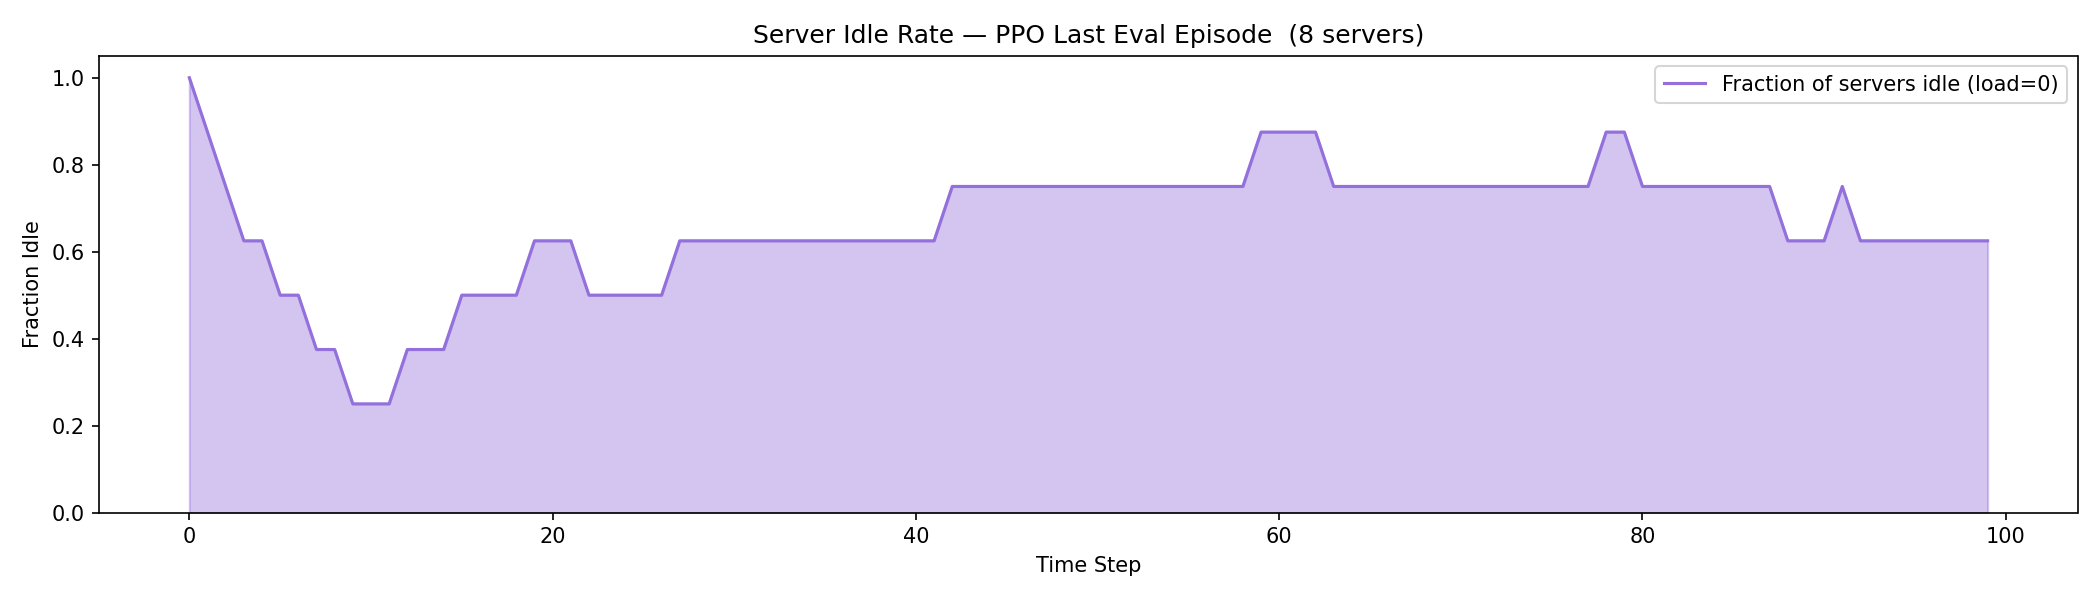

In [ ]:
from IPython.display import Image
Image('output/sleep_analysis.png')

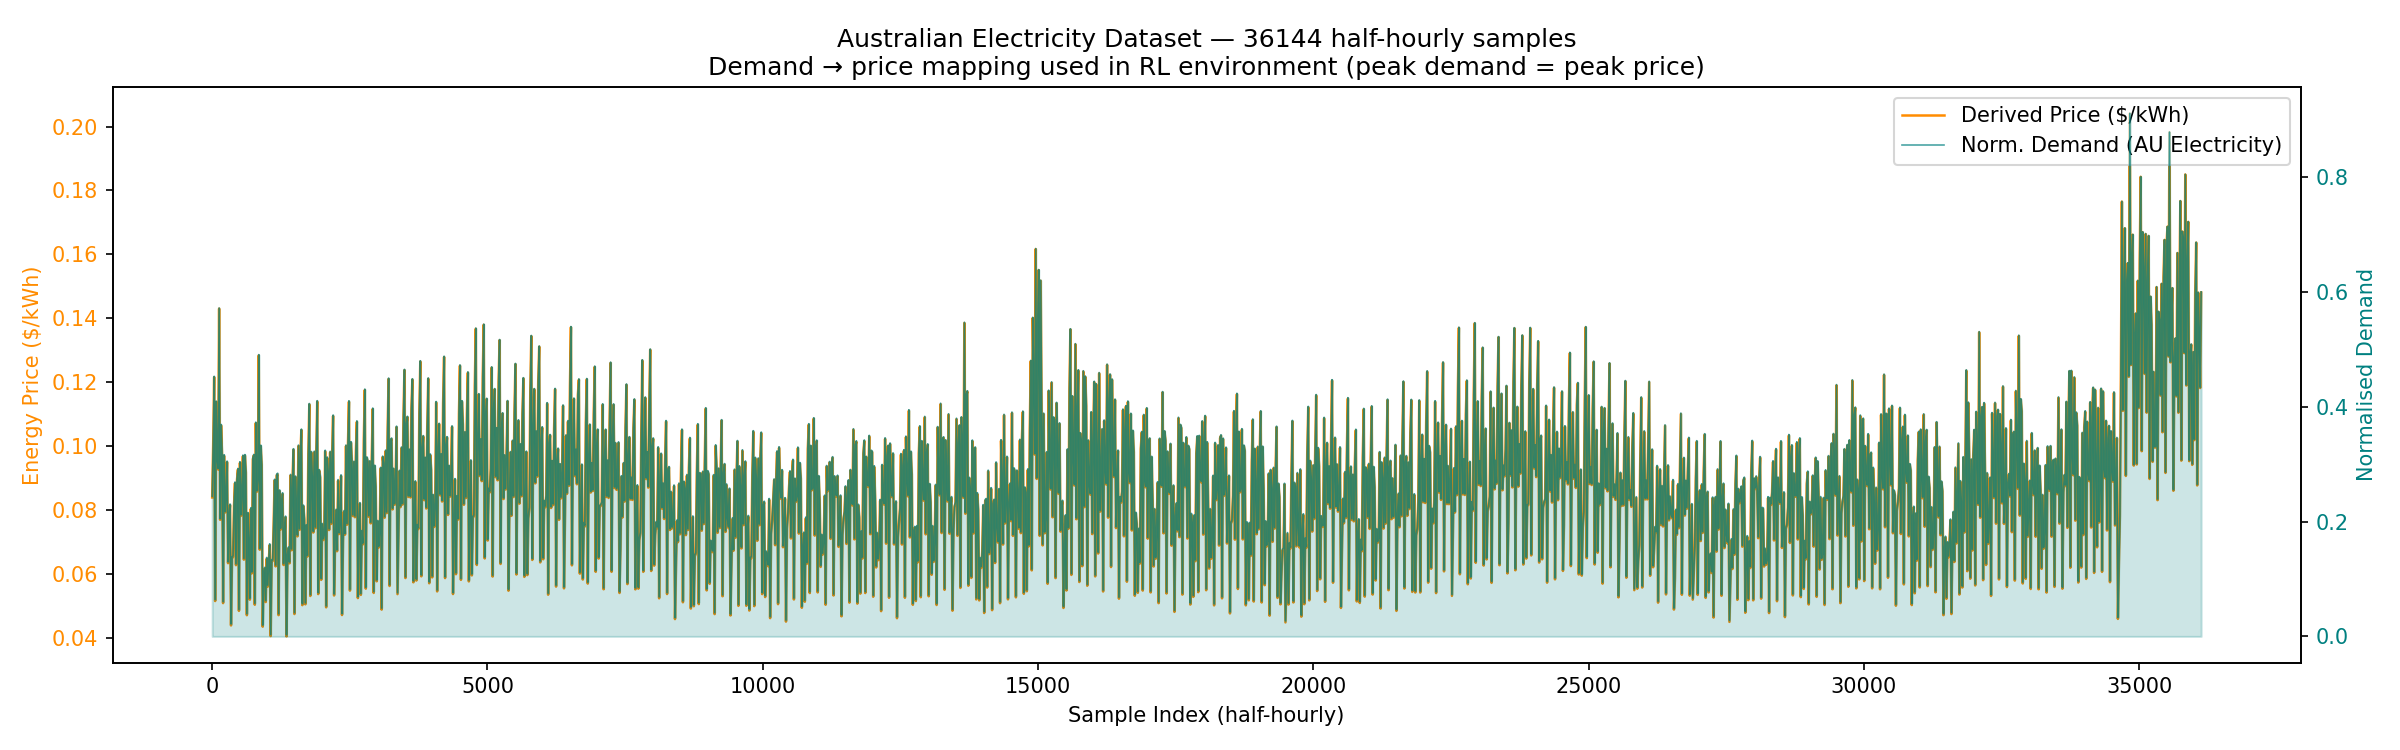

In [ ]:
from IPython.display import Image
Image('output/real_demand_vs_price.png')

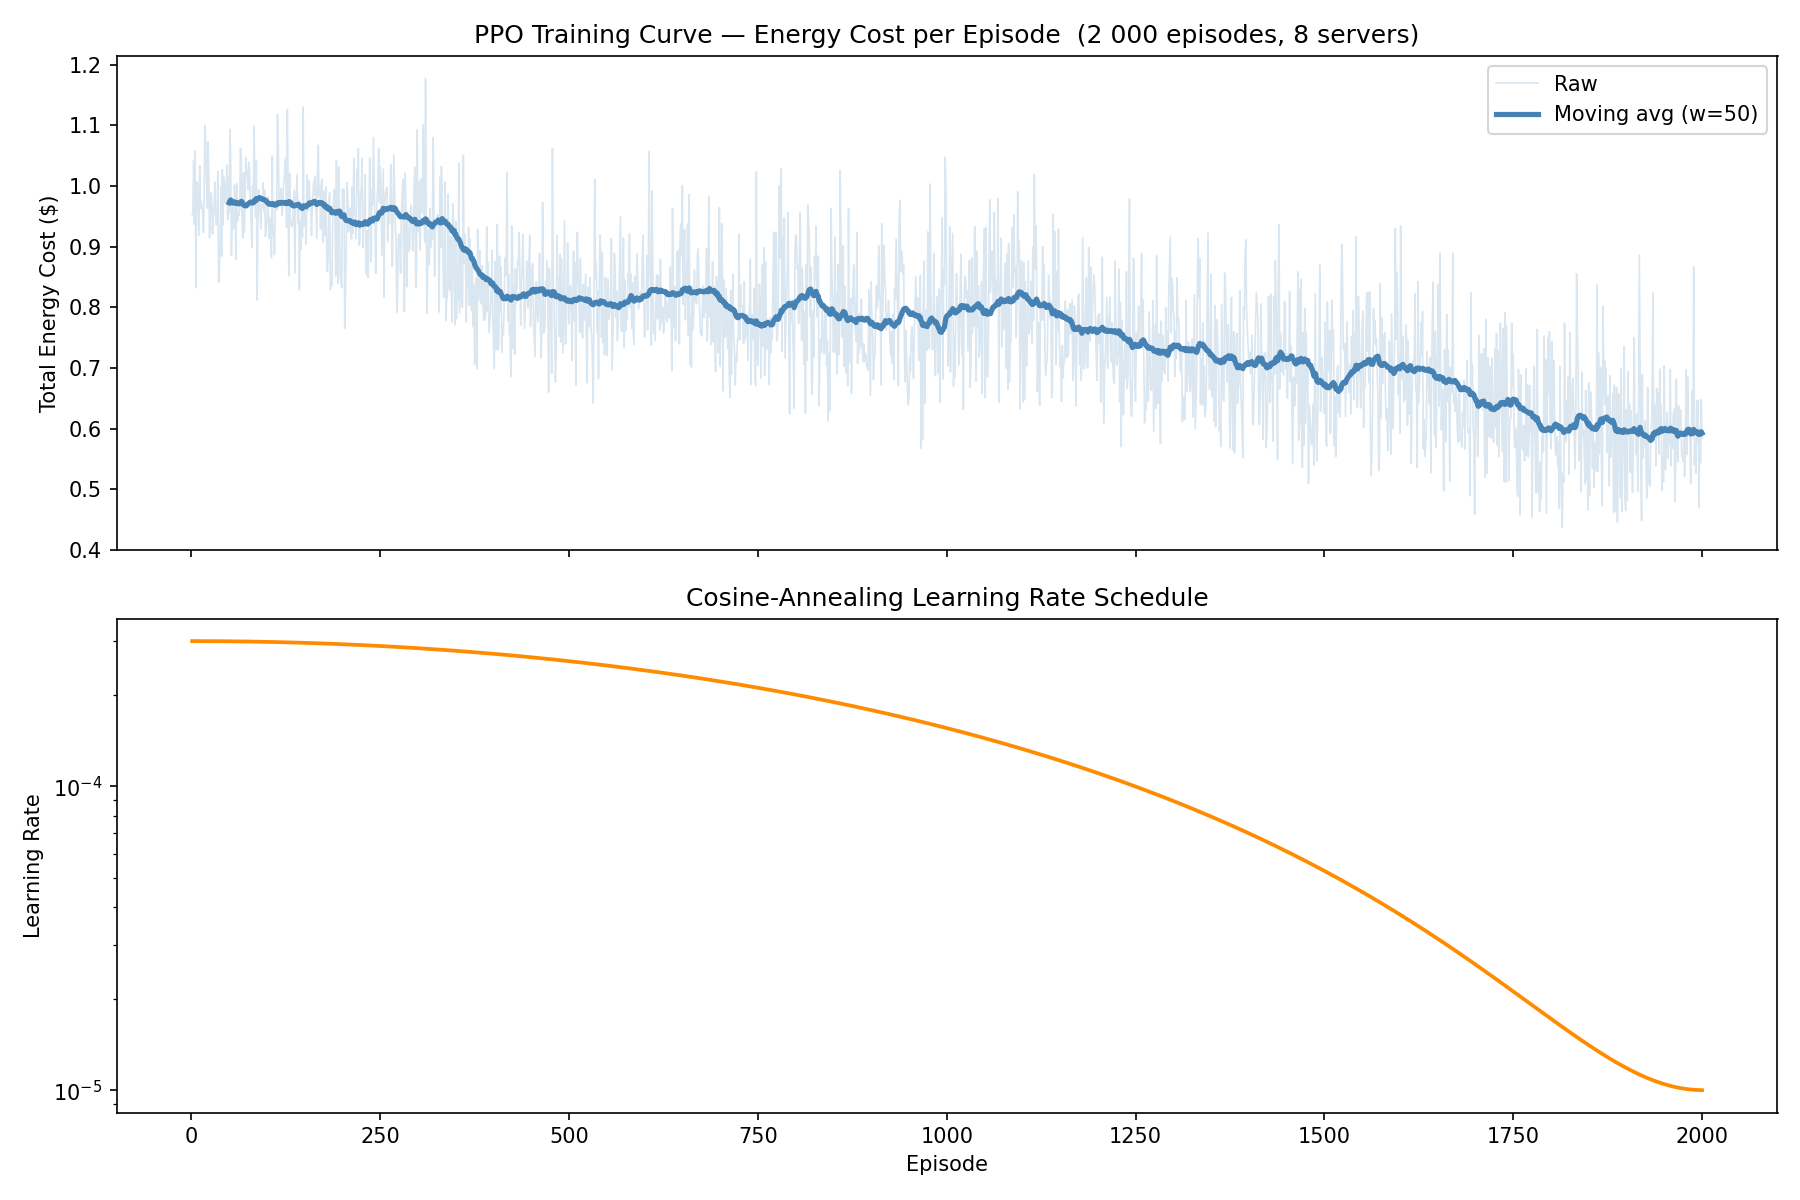

In [ ]:
from IPython.display import Image
Image('output/training_curve.png')

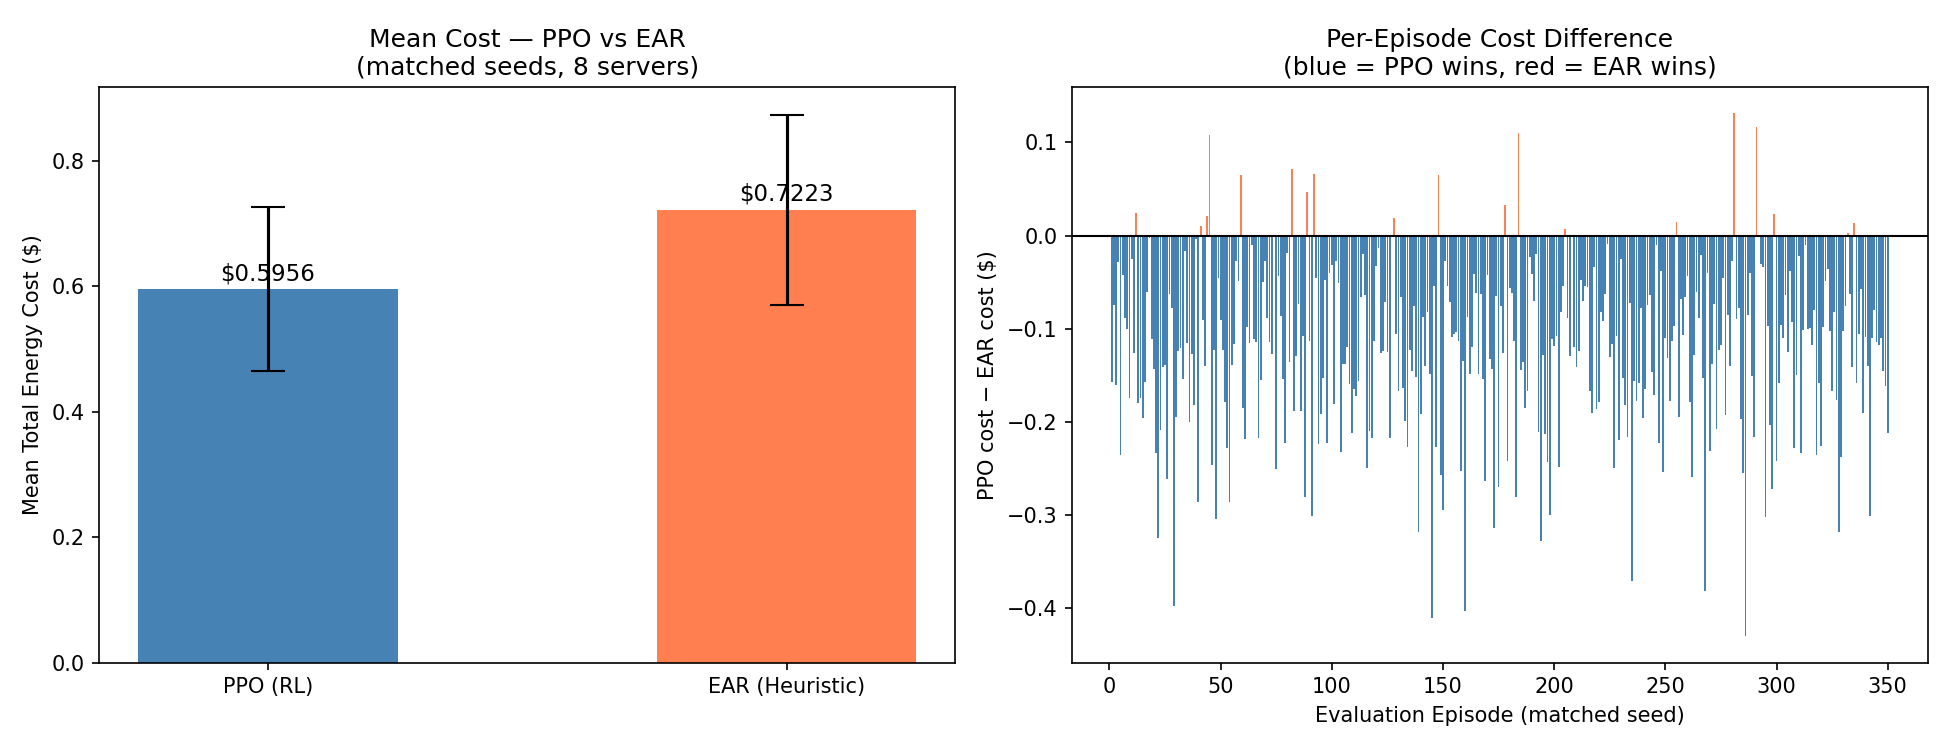

In [ ]:
from IPython.display import Image
Image('output/energy_comparison.png')

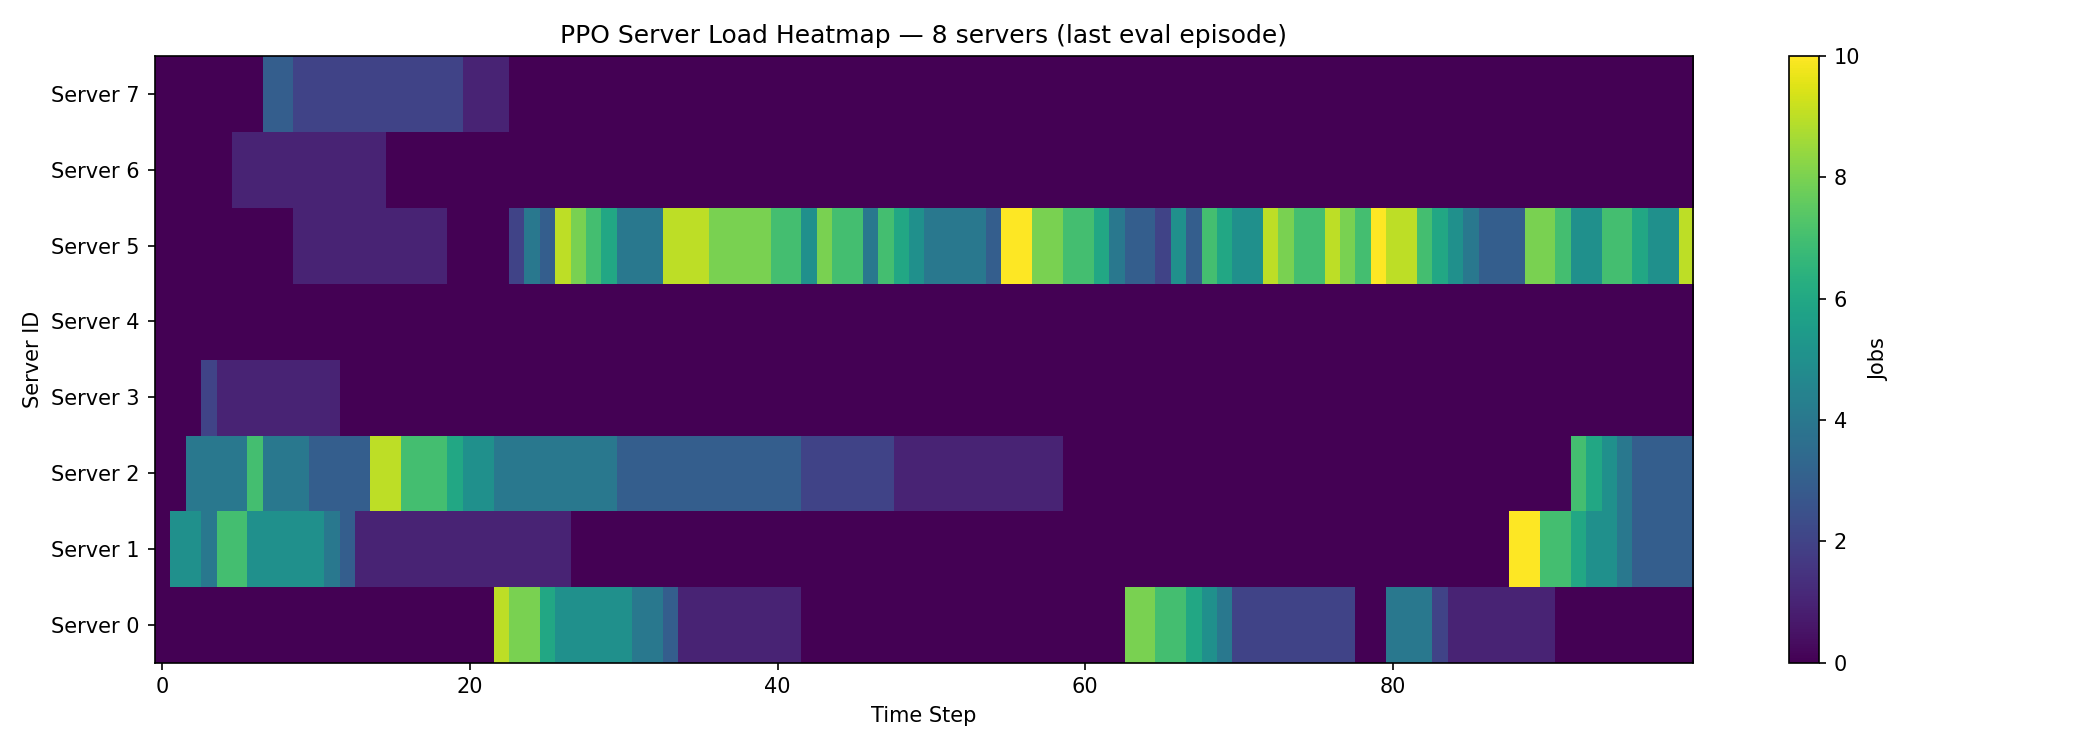

In [ ]:
from IPython.display import Image
Image('output/load_heatmap_ppo.png')

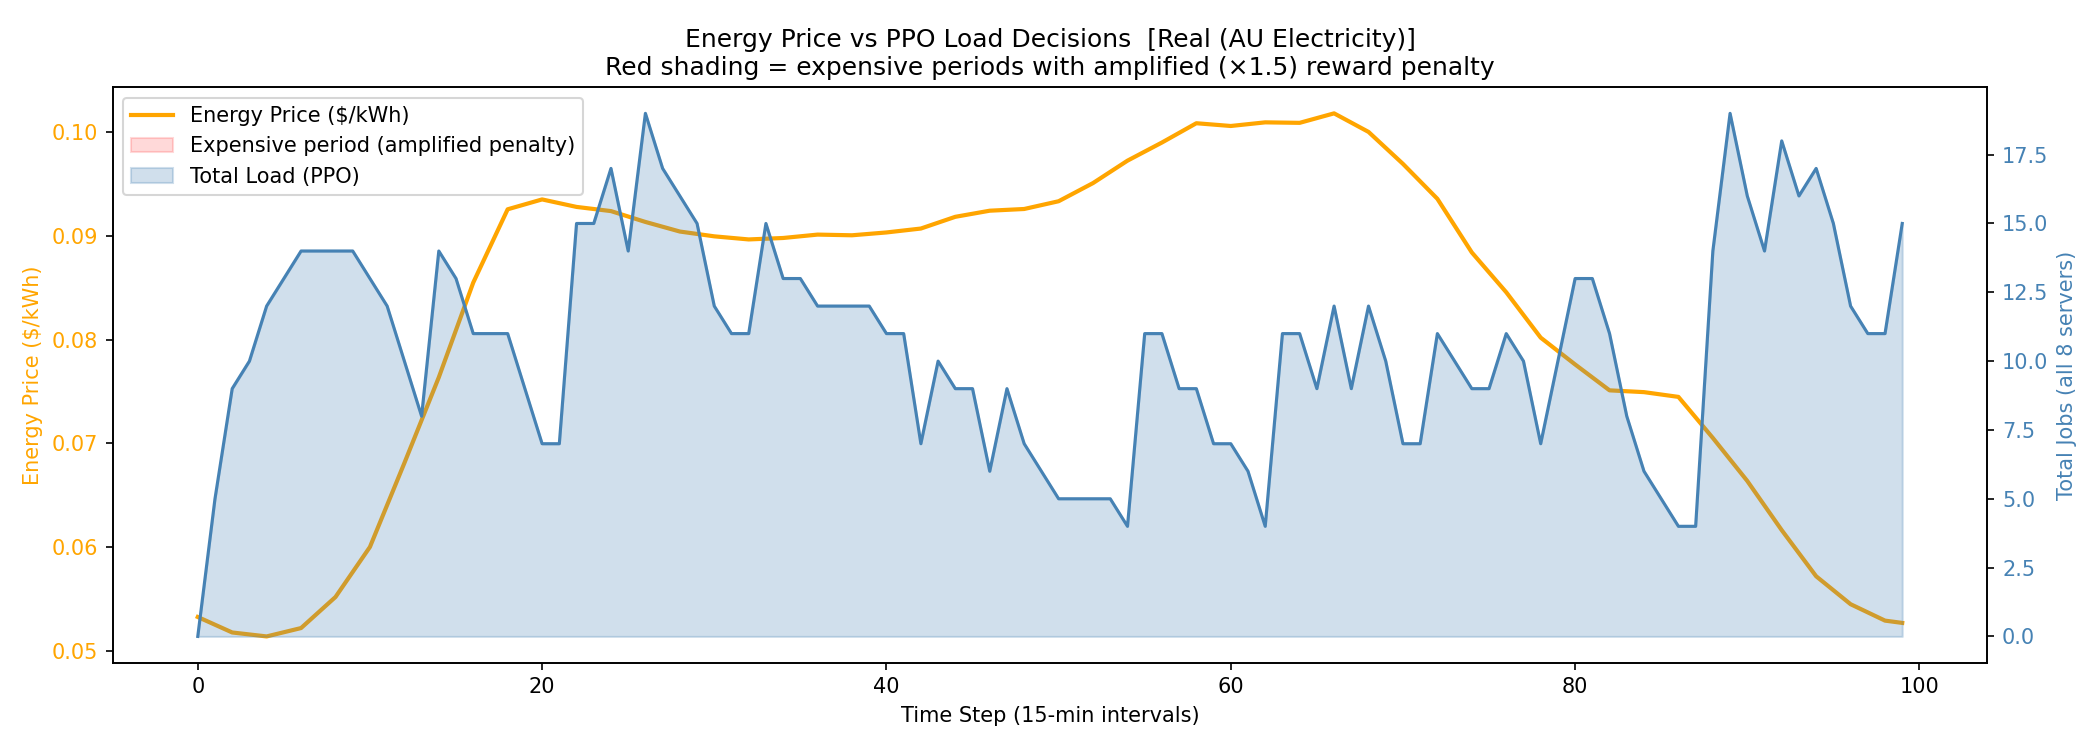

In [ ]:
from IPython.display import Image
Image('output/price_curve.png')